# AI312 — Sentiment Detection and Negative Tone Rewriting System
**Dataset:** IMDB Movie Reviews (50,000 reviews) | **Models:** Logistic Regression · SVM · CNN

## Step 0: Install Dependencies

In [61]:
!pip install scikit-learn tensorflow nltk pandas numpy ipywidgets --quiet
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
print("All dependencies installed.")

All dependencies installed.


In [44]:
!pip install scikit-learn tensorflow nltk pandas numpy ipywidgets gensim --quiet

## Step 1: Imports

In [45]:
import re
import string
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print("Imports done.")

Imports done.


## Step 2: Load Dataset

In [46]:
df = pd.read_csv("IMDB Dataset.csv")
print("Shape:", df.shape)
print(df["sentiment"].value_counts())
df.head(3)

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


## Step 3: Text Preprocessing
We apply: lowercasing → HTML tag removal → URL removal → punctuation removal → digit removal → stopword removal → lemmatization.

In [47]:
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>",  " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+",    " ", text)
    text = re.sub(r"\s+",    " ", text).strip()
    return text

def preprocess_text(text):
    text   = clean_text(text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS]  # stopword removal
    tokens = [lemmatizer.lemmatize(w) for w in tokens]           # lemmatization
    tokens = [stemmer.stem(w) for w in tokens]                   # stemming
    return " ".join(tokens)

df["clean_review"] = df["review"].apply(preprocess_text)
df["label"]        = df["sentiment"].map({"positive": 1, "negative": 0})

print("Preprocessing complete.")
print(f"\nOriginal : {df['review'].iloc[0][:100]}...")
print(f"Cleaned  : {df['clean_review'].iloc[0][:100]}...")

Preprocessing complete.

Original : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The...
Cleaned  : review mention watch just oz episod youll hook right exactli happen thing struck oz brutal unflinch ...


## Step 4: Train / Test Split

In [48]:
X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 40,000 | Test: 10,000


## Step 5: TF-IDF Vectorization

In [49]:
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec

# ── 1. Bag-of-Words ──────────────────────────────────────────────────────────
bow_vectorizer = CountVectorizer(max_features=10000)
X_train_bow    = bow_vectorizer.fit_transform(X_train)
X_test_bow     = bow_vectorizer.transform(X_test)
print("BoW shape:", X_train_bow.shape)

# ── 2. TF-IDF ────────────────────────────────────────────────────────────────
vectorizer     = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf  = vectorizer.fit_transform(X_train)
X_test_tfidf   = vectorizer.transform(X_test)
print("TF-IDF shape:", X_train_tfidf.shape)

# ── 3. Word2Vec (mean pooling) ────────────────────────────────────────────────
tokenized_train = [text.split() for text in X_train]
tokenized_test  = [text.split() for text in X_test]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5
)

def get_w2v_vector(tokens, model, size=100):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

X_train_w2v = np.array([get_w2v_vector(t, w2v_model) for t in tokenized_train])
X_test_w2v  = np.array([get_w2v_vector(t, w2v_model) for t in tokenized_test])
print("Word2Vec shape:", X_train_w2v.shape)

BoW shape: (40000, 10000)
TF-IDF shape: (40000, 10000)
Word2Vec shape: (40000, 100)


In [50]:
# ── Baseline: Logistic Regression on all 3 representations ───────────────────
from sklearn.metrics import accuracy_score, f1_score

baseline_results = {}

for name, X_tr, X_te in [
    ("Bag-of-Words", X_train_bow,   X_test_bow),
    ("TF-IDF",       X_train_tfidf, X_test_tfidf),
    ("Word2Vec",     X_train_w2v,   X_test_w2v),
]:
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    baseline_results[name] = {
        "Accuracy":  round(accuracy_score(y_test, preds), 4),
        "F1-Score":  round(f1_score(y_test, preds), 4),
    }

print("=" * 42)
print(f"{'Representation':<18} {'Accuracy':>9} {'F1-Score':>9}")
print("=" * 42)
for rep, scores in baseline_results.items():
    print(f"{rep:<18} {scores['Accuracy']:>9} {scores['F1-Score']:>9}")
print("=" * 42)

Representation      Accuracy  F1-Score
Bag-of-Words          0.8711    0.8716
TF-IDF                0.8935    0.8945
Word2Vec              0.8534    0.8545


## Step 6: Logistic Regression

In [51]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec  = recall_score(y_test, y_pred_lr)
lr_f1   = f1_score(y_test, y_pred_lr)

print("===== Logistic Regression =====")
print(f"Accuracy:  {lr_acc:.4f}")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall:    {lr_rec:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=["Negative", "Positive"]))
print(confusion_matrix(y_test, y_pred_lr))

===== Logistic Regression =====
Accuracy:  0.8935
Precision: 0.8863
Recall:    0.9028
F1-Score:  0.8945

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4421  579]
 [ 486 4514]]


## Step 7: SVM (LinearSVC)

In [52]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_rec  = recall_score(y_test, y_pred_svm)
svm_f1   = f1_score(y_test, y_pred_svm)

print("===== SVM (LinearSVC) =====")
print(f"Accuracy:  {svm_acc:.4f}")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall:    {svm_rec:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=["Negative", "Positive"]))
print(confusion_matrix(y_test, y_pred_svm))

===== SVM (LinearSVC) =====
Accuracy:  0.8845
Precision: 0.8784
Recall:    0.8926
F1-Score:  0.8854

              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      5000
    Positive       0.88      0.89      0.89      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

[[4382  618]
 [ 537 4463]]


## Step 8: CNN Model

In [53]:
MAX_WORDS = 20000
MAX_LEN   = 200

cnn_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
cnn_tokenizer.fit_on_texts(X_train)

X_train_seq = cnn_tokenizer.texts_to_sequences(X_train)
X_test_seq  = cnn_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

cnn_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = cnn_model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_pad, y_test, verbose=0)

y_pred_cnn_prob = cnn_model.predict(X_test_pad, verbose=0)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype("int32").flatten()

cnn_prec = precision_score(y_test, y_pred_cnn)
cnn_rec  = recall_score(y_test, y_pred_cnn)
cnn_f1   = f1_score(y_test, y_pred_cnn)

print("===== CNN =====")
print(f"Accuracy:  {cnn_acc:.4f}")
print(f"Precision: {cnn_prec:.4f}")
print(f"Recall:    {cnn_rec:.4f}")
print(f"F1-Score:  {cnn_f1:.4f}")
print()
print(classification_report(y_test, y_pred_cnn, target_names=["Negative", "Positive"]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 405ms/step - accuracy: 0.7756 - loss: 0.4553 - val_accuracy: 0.8671 - val_loss: 0.3100
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 406ms/step - accuracy: 0.9127 - loss: 0.2334 - val_accuracy: 0.8805 - val_loss: 0.2888
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 404ms/step - accuracy: 0.9721 - loss: 0.0929 - val_accuracy: 0.8730 - val_loss: 0.3519
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 404ms/step - accuracy: 0.9953 - loss: 0.0247 - val_accuracy: 0.8781 - val_loss: 0.4044
===== CNN =====
Accuracy:  0.8765
Precision: 0.8767
Recall:    0.8762
F1-Score:  0.8765

              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      5000
    Positive       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## Step 9: Model Comparison

In [54]:
comparison = pd.DataFrame({
    "Model":     ["Logistic Regression", "SVM (LinearSVC)", "CNN"],
    "Accuracy":  [round(lr_acc,4),  round(svm_acc,4),  round(cnn_acc,4)],
    "Precision": [round(lr_prec,4), round(svm_prec,4), round(cnn_prec,4)],
    "Recall":    [round(lr_rec,4),  round(svm_rec,4),  round(cnn_rec,4)],
    "F1-Score":  [round(lr_f1,4),   round(svm_f1,4),   round(cnn_f1,4)],
})

comparison = comparison.set_index("Model")
print(comparison.to_string())

best_model_name = comparison["F1-Score"].idxmax()
print(f"Best model by F1-Score: {best_model_name}")

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.8935     0.8863  0.9028    0.8945
SVM (LinearSVC)        0.8845     0.8784  0.8926    0.8854
CNN                    0.8765     0.8767  0.8762    0.8765
Best model by F1-Score: Logistic Regression


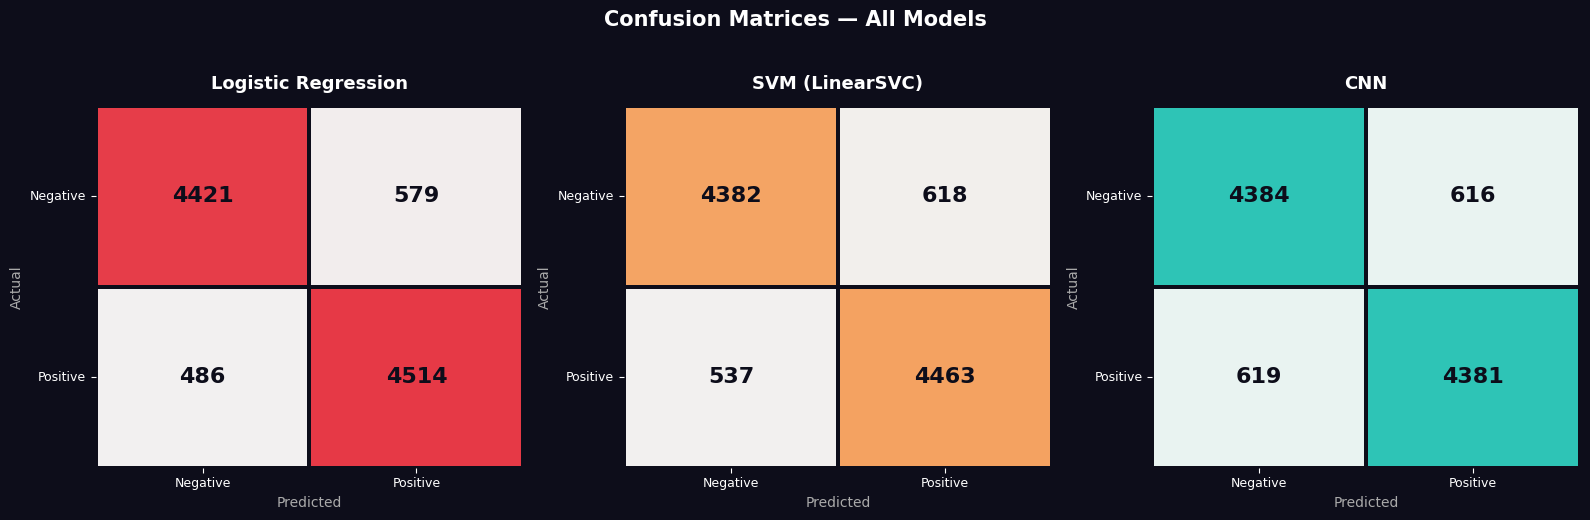

In [55]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

fig = plt.figure(figsize=(16, 5))
fig.patch.set_facecolor("#0d0d1a")

models_info = [
    ("Logistic Regression", y_pred_lr,  "#e63946"),
    ("SVM (LinearSVC)",     y_pred_svm, "#f4a261"),
    ("CNN",                 y_pred_cnn, "#2ec4b6"),
]

for i, (name, preds, color) in enumerate(models_info):
    ax = fig.add_subplot(1, 3, i + 1)
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette(color, as_cmap=True),
        linewidths=1.5,
        linecolor="#0d0d1a",
        ax=ax,
        cbar=False,
        annot_kws={"size": 16, "weight": "bold", "color": "#0d0d1a"}
    )

    ax.set_facecolor("#0d0d1a")
    ax.set_title(name, color="white", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted", color="#aaaaaa", fontsize=10)
    ax.set_ylabel("Actual",    color="#aaaaaa", fontsize=10)
    ax.set_xticklabels(["Negative", "Positive"], color="white", fontsize=9)
    ax.set_yticklabels(["Negative", "Positive"], color="white", fontsize=9, rotation=0)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333355")

plt.suptitle("Confusion Matrices — All Models", color="white", fontsize=15,
             fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight",
            facecolor="#0d0d1a")
plt.show()

## Step 10:  Negative Tone Rewriting

In [69]:
!pip install google-genai --quiet
from google.colab import userdata
from google import genai
import time

client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))

CANDIDATES = ["gemini-3.5-flash", "gemini-3.6-flash", "gemini-2.0-flash",
              "gemini-3.5-flash-lite", "gemini-2.5-flash-lite"]
MODEL_IDX = 0                      # renamed — never use _i in a notebook
print("Starting with:", CANDIDATES[MODEL_IDX])

Starting with: gemini-3.5-flash


In [74]:
SYSTEM = (
    "You rewrite negative movie reviews into a constructive, respectful tone.\n"
    "Rules:\n"
    "- Keep the specific criticisms and concrete details from the original.\n"
    "- Do NOT make it positive and do NOT invent anything.\n"
    "- Keep it roughly the same length.\n"
    "- Return ONLY the rewritten review, no preamble."
)

def rewrite_negative_tone(text):
    global MODEL_IDX
    while MODEL_IDX < len(CANDIDATES):
        try:
            r = client.models.generate_content(
                model=CANDIDATES[MODEL_IDX],
                contents=f"{SYSTEM}\n\nReview:\n{text}"
            )
            return r.text.strip()
        except Exception as e:
            if "RESOURCE_EXHAUSTED" in str(e):
                MODEL_IDX += 1
                nxt = CANDIDATES[MODEL_IDX] if MODEL_IDX < len(CANDIDATES) else "none left"
                print(f"quota hit -> switching to {nxt}")
                continue
            return f"[rewrite failed: {e}]"
    return "[all models exhausted for today]"

In [77]:
test_review = (
    "I went in expecting a decent thriller and got two hours of nothing. "
    "The pacing is painfully slow, the lead actor delivers every line like he's "
    "reading off a cue card, and the plot twist in the third act makes no sense "
    "given everything set up earlier. The cinematography is the only thing that "
    "isn't embarrassing. Honestly a waste of money and I regret not walking out."
)
print(rewrite_negative_tone(test_review))

server busy, retrying in 2s...
server busy, retrying in 4s...
server busy, retrying in 8s...
server busy, retrying in 16s...
still busy -> switching model
While I hoped for a solid thriller, the two-hour runtime ultimately lacked engaging substance. The pacing feels excessively slow, and the lead actor’s performance lacks natural expression, delivering dialogue as if reading directly off a card. Additionally, the third-act plot twist conflicts logically with the earlier setup. The cinematography stands out as the movie's only strong element. Ultimately, the experience felt like an unwise investment of time and money, making it difficult to stay until the end.


In [76]:
def rewrite_negative_tone(text, max_tries=4):
    global MODEL_IDX
    tries = 0
    while MODEL_IDX < len(CANDIDATES):
        try:
            r = client.models.generate_content(
                model=CANDIDATES[MODEL_IDX],
                contents=f"{SYSTEM}\n\nReview:\n{text}"
            )
            return r.text.strip()
        except Exception as e:
            msg = str(e)
            if "RESOURCE_EXHAUSTED" in msg:
                MODEL_IDX += 1                 # daily cap — waiting won't help
                nxt = CANDIDATES[MODEL_IDX] if MODEL_IDX < len(CANDIDATES) else "none left"
                print(f"quota hit -> switching to {nxt}")
                continue
            if ("503" in msg or "UNAVAILABLE" in msg) and tries < max_tries:
                tries += 1
                wait = 2 ** tries              # 2s, 4s, 8s, 16s
                print(f"server busy, retrying in {wait}s...")
                time.sleep(wait)
                continue
            if "503" in msg or "UNAVAILABLE" in msg:
                MODEL_IDX += 1                 # still busy — try a different model
                tries = 0
                print("still busy -> switching model")
                continue
            return f"[rewrite failed: {e}]"
    return "[all models exhausted]"

## Step 11: Full Analysis Pipeline

In [57]:
# Use Logistic Regression as the default model (best balance of speed + accuracy)
FINAL_MODEL = lr_model
def analyze_and_rewrite_model(text, model="lr"):
    """Same as analyze_and_rewrite but lets you pick the model."""
    processed = preprocess_text(text)

    if model in ("lr", "svm"):
        vec = vectorizer.transform([processed])
        pred = lr_model.predict(vec)[0] if model == "lr" else svm_model.predict(vec)[0]
    else:  # cnn
        seq = cnn_tokenizer.texts_to_sequences([processed])
        pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
        pred = int(cnn_model.predict(pad, verbose=0)[0][0] > 0.5)

    if pred == 1:
        return "Positive", "No rewriting needed — the tone is already positive!", "positive"
    else:
        return "Negative", rewrite_negative_tone(text), "negative"

## Step 12: Interactive Demo (ipywidgets GUI)

In [78]:
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@300;400;500;600&family=Syne:wght@700;800&display=swap');
.app{background:#080810;border-radius:20px;overflow:hidden;font-family:'Space Grotesk',sans-serif;color:#e0e0f0;max-width:700px;margin:0 auto;}
.topbar{padding:24px 28px 20px;border-bottom:1px solid #13132a;}
.brand{display:flex;align-items:center;gap:14px;margin-bottom:20px;}
.brand-icon{width:42px;height:42px;border-radius:10px;background:#ff2d55;display:flex;align-items:center;justify-content:center;font-size:20px;}
.brand-name{font-family:'Syne',sans-serif;font-size:20px;font-weight:800;color:#fff;letter-spacing:-.3px;}
.brand-tag{font-size:11px;color:#444466;letter-spacing:.1em;text-transform:uppercase;margin-top:1px;}
.model-row{display:flex;gap:8px;}
.model-chip{flex:1;padding:9px 0;border-radius:8px;border:1px solid #1a1a30;background:#0d0d1e;font-size:12px;font-weight:500;color:#555580;cursor:pointer;text-align:center;letter-spacing:.03em;transition:all .18s;}
.model-chip:hover{border-color:#333360;color:#9999cc;}
.sel-lr{background:#1a0520 !important;border-color:#ff2d55 !important;color:#ff2d55 !important;}
.sel-svm{background:#050d20 !important;border-color:#0ea5e9 !important;color:#38bdf8 !important;}
.sel-cnn{background:#020d14 !important;border-color:#06b6d4 !important;color:#22d3ee !important;}
.sel-all{background:#0d1a0d !important;border-color:#a855f7 !important;color:#c084fc !important;}
.body-wrap{padding:22px 28px 28px;}
.field-label{font-size:10px;font-weight:600;letter-spacing:.12em;text-transform:uppercase;color:#333355;margin-bottom:8px;}
.result-wrap{border-radius:14px;overflow:hidden;border:1px solid #1a1a30;}
.result-head{padding:18px 22px;display:flex;align-items:center;gap:12px;flex-wrap:wrap;}
.rh-pos{background:#071a0f;} .rh-neg{background:#180709;}
.sent-pill{font-size:11px;font-weight:600;padding:5px 14px;border-radius:20px;letter-spacing:.05em;text-transform:uppercase;}
.sp-pos{background:#0d3320;color:#34d399;} .sp-neg{background:#3a0d12;color:#f87171;}
.sent-label{font-size:14px;font-weight:500;color:#d0d0e8;}
.conf-wrap{margin-left:auto;text-align:right;}
.conf-num{font-family:'Syne',sans-serif;font-size:22px;font-weight:800;color:#fff;}
.conf-lbl{font-size:10px;color:#444466;letter-spacing:.08em;text-transform:uppercase;}
.model-tag{font-size:10px;letter-spacing:.07em;text-transform:uppercase;padding:3px 10px;border-radius:6px;font-weight:600;}
.mut-lr{background:#2a0515;color:#ff2d55;} .mut-svm{background:#051525;color:#38bdf8;} .mut-cnn{background:#021018;color:#22d3ee;}
.meter-section{background:#0d0d1e;padding:16px 22px;border-top:1px solid #13132a;}
.meter-row{display:flex;align-items:center;gap:12px;margin-bottom:10px;}
.meter-row:last-child{margin-bottom:0;}
.meter-name{font-size:11px;color:#444466;width:60px;flex-shrink:0;}
.meter-track{flex:1;height:4px;background:#13132a;border-radius:2px;overflow:hidden;}
.meter-fill{height:100%;border-radius:2px;}
.mf-pos{background:#34d399;} .mf-neg{background:#f87171;}
.meter-val{font-size:12px;font-weight:600;width:40px;text-align:right;flex-shrink:0;}
.rewrite-section{background:#100a18;padding:16px 22px;border-top:1px solid #1a1a30;}
.rw-head{display:flex;align-items:center;gap:8px;margin-bottom:10px;}
.rw-dot{width:6px;height:6px;border-radius:50%;background:#a855f7;flex-shrink:0;}
.rw-lbl{font-size:10px;font-weight:600;letter-spacing:.1em;text-transform:uppercase;color:#6633aa;}
.rw-text{font-size:14px;color:#c084fc;line-height:1.75;font-style:italic;}
.all-results{display:flex;flex-direction:column;gap:12px;}
.mini-card{border-radius:12px;border:1px solid #1a1a30;overflow:hidden;}
.mini-head{padding:13px 18px;display:flex;align-items:center;gap:10px;}
.mini-conf{margin-left:auto;font-family:'Syne',sans-serif;font-size:18px;font-weight:800;color:#fff;}
.mini-body{background:#0d0d1e;padding:12px 18px;border-top:1px solid #13132a;font-size:13px;}
.mini-rw{color:#c084fc;font-style:italic;line-height:1.65;}
.mini-norw{color:#34d399;}
.ph-state{padding:36px;text-align:center;color:#222235;font-size:13px;}
</style>
"""))

# ── Model selector buttons ─────────────────────────────────────────────────
active_model = {"value": "lr"}

btn_lr  = widgets.ToggleButton(value=True,  description="Logistic Regression", layout=widgets.Layout(width="auto", height="36px"))
btn_svm = widgets.ToggleButton(value=False, description="SVM",                 layout=widgets.Layout(width="auto", height="36px"))
btn_cnn = widgets.ToggleButton(value=False, description="CNN",                 layout=widgets.Layout(width="auto", height="36px"))
btn_all = widgets.ToggleButton(value=False, description="All Models",          layout=widgets.Layout(width="auto", height="36px"))

def switch(m, b):
    active_model["value"] = m
    for btn, key in [(btn_lr,"lr"),(btn_svm,"svm"),(btn_cnn,"cnn"),(btn_all,"all")]:
        btn.value = (key == m)

btn_lr.observe(lambda b: switch("lr", b)  if b["new"] else None, names="value")
btn_svm.observe(lambda b: switch("svm", b) if b["new"] else None, names="value")
btn_cnn.observe(lambda b: switch("cnn", b) if b["new"] else None, names="value")
btn_all.observe(lambda b: switch("all", b) if b["new"] else None, names="value")

# ── Review textarea + buttons ──────────────────────────────────────────────
textarea = widgets.Textarea(
    placeholder="Write or paste any movie review...",
    layout=widgets.Layout(width="100%", height="96px")
)

btn_analyze = widgets.Button(description="Analyze",
                              button_style="danger",
                              layout=widgets.Layout(width="120px", height="38px"))
btn_clear   = widgets.Button(description="Clear",
                              layout=widgets.Layout(width="80px",  height="38px"))
output_area = widgets.Output()

def get_confidence(text, is_neg, model):
    """
    Real confidence: use predict_proba for LR, decision_function for SVM,
    and sigmoid output probability for CNN.
    """
    processed = preprocess_text(text)
    if model == "lr":
        vec = vectorizer.transform([processed])
        prob = lr_model.predict_proba(vec)[0]
        return float(prob[1]) if not is_neg else float(prob[0])
    elif model == "svm":
        vec = vectorizer.transform([processed])
        score = svm_model.decision_function(vec)[0]
        import math
        conf = 1 / (1 + math.exp(-abs(score)))
        return float(conf)
    elif model == "cnn":
        seq = cnn_tokenizer.texts_to_sequences([processed])
        pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
        prob = float(cnn_model.predict(pad, verbose=0)[0][0])
        return prob if not is_neg else (1 - prob)

def render_single(text, model):
    sentiment, improved, label = analyze_and_rewrite_model(text, model)
    is_neg = (label == "negative")
    conf = get_confidence(text, is_neg, model)
    conf_pct = f"{conf*100:.1f}%"
    pos_conf = conf if not is_neg else (1-conf)
    neg_conf = conf if is_neg else (1-conf)
    model_labels = {"lr":"Logistic Regression","svm":"SVM","cnn":"CNN"}
    rh = "rh-neg" if is_neg else "rh-pos"
    sp = "sp-neg" if is_neg else "sp-pos"
    sl = "Negative" if is_neg else "Positive"
    mt = f"mut-{model}"
    rewrite_html = f"""
    <div class="rewrite-section">
      <div class="rw-head"><div class="rw-dot"></div><div class="rw-lbl">Professional rewrite</div></div>
      <div class="rw-text">{improved}</div>
    </div>""" if is_neg else ""
    return f"""
    <div class="result-wrap">
      <div class="result-head {rh}">
        <span class="sent-pill {sp}">{sl}</span>
        <span class="sent-label">{'Negative tone detected' if is_neg else 'Positive tone detected'}</span>
        <span class="model-tag {mt}">{model_labels[model]}</span>
        <div class="conf-wrap"><div class="conf-num">{conf_pct}</div><div class="conf-lbl">confidence</div></div>
      </div>
      <div class="meter-section">
        <div class="meter-row">
          <span class="meter-name">Positive</span>
          <div class="meter-track"><div class="meter-fill mf-pos" style="width:{pos_conf*100:.1f}%"></div></div>
          <span class="meter-val" style="color:#34d399">{pos_conf*100:.1f}%</span>
        </div>
        <div class="meter-row">
          <span class="meter-name">Negative</span>
          <div class="meter-track"><div class="meter-fill mf-neg" style="width:{neg_conf*100:.1f}%"></div></div>
          <span class="meter-val" style="color:#f87171">{neg_conf*100:.1f}%</span>
        </div>
      </div>
      {rewrite_html}
    </div>"""

def render_all(text):
    cards = ""
    for m, ml in [("lr","Logistic Regression"),("svm","SVM"),("cnn","CNN")]:
        sentiment, improved, label = analyze_and_rewrite_model(text, m)
        is_neg = (label == "negative")
        conf = get_confidence(text, is_neg, m)
        rh = "rh-neg" if is_neg else "rh-pos"
        sp = "sp-neg" if is_neg else "sp-pos"
        sl = "Negative" if is_neg else "Positive"
        body = f'<div class="mini-rw">{improved}</div>' if is_neg else '<div class="mini-norw">No rewriting needed — tone is positive.</div>'
        cards += f"""
        <div class="mini-card">
          <div class="mini-head {rh}">
            <span class="sent-pill {sp}">{sl}</span>
            <span class="sent-label" style="font-size:13px">{ml}</span>
            <div class="mini-conf">{conf*100:.1f}%</div>
          </div>
          <div class="mini-body">{body}</div>
        </div>"""
    return f'<div class="all-results">{cards}</div>'

def on_analyze(b):
    with output_area:
        clear_output(wait=True)
        text = textarea.value.strip()
        if not text:
            display(HTML('<div class="ph-state">Please enter a review.</div>'))
            return
        m = active_model["value"]
        html = render_all(text) if m == "all" else render_single(text, m)
        display(HTML(html))

def on_clear(b):
    textarea.value = ""
    with output_area:
        clear_output()

btn_analyze.on_click(on_analyze)
btn_clear.on_click(on_clear)

display(HTML('<div class="app"><div class="topbar"><div class="brand"><div class="brand-icon">&#127916;</div><div><div class="brand-name">Sentiment Detection and Negative Tone Rewriting System</div><div class="brand-tag">Sentiment · Confidence · Rewriter</div></div></div><div class="field-label" style="margin-bottom:8px">Select model</div>'))
display(widgets.HBox([btn_lr, btn_svm, btn_cnn, btn_all], layout=widgets.Layout(gap="8px")))
display(HTML('</div><div class="body-wrap"><div class="field-label">Movie review</div>'))
display(textarea)
display(widgets.HBox([btn_analyze, btn_clear], layout=widgets.Layout(margin="12px 0 0", gap="10px")))
display(HTML('<div style="height:1px;background:#13132a;margin:20px 0"></div>'))
display(output_area)
display(HTML('</div></div>'))

Textarea(value='', layout=Layout(height='96px', width='100%'), placeholder='Write or paste any movie review...…

Output()